# Test of the Reciever Simulator


In [7]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

from utils.utils import gamma_db_to_impedence
import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [8]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/Receiver_01.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p',
                         t_unc_scale=240,
                         t_cos_scale=-166,
                         t_sin_scale=58)

test_receiver.change_freqs(np.linspace(65*un.MHz, 75*un.MHz, 2048))

open_load = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e2_open.s2p',
                 freqs=test_receiver.freqs,
                 label='open')

open_load.change_freqs(test_receiver.freqs)

short_load = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e3_short.s2p',
                 freqs=test_receiver.freqs,
                 label='short')

short_load.change_freqs(test_receiver.freqs)

long_open = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e5_longopen.s2p',
                 freqs=test_receiver.freqs,
                 label='long_open')

long_open.change_freqs(test_receiver.freqs)

long_short = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t2t2e5_longshort.s2p',
                 freqs=test_receiver.freqs,
                 label='long_short')

long_short.change_freqs(test_receiver.freqs)

matched_ambient = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e1_load.s2p',
                 freqs=test_receiver.freqs,
                 label='internal_load')

matched_ambient.change_freqs(test_receiver.freqs)

heated_load = Load(physical_temperature=273+55,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e6_heatedload.s2p',
                 freqs=test_receiver.freqs,
                 label='heated_load')

heated_load.change_freqs(test_receiver.freqs)

test_src = Load(physical_temperature=273+22,
                 gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e8_testsrc.s2p',
                 freqs=test_receiver.freqs,
                 label='test_src')
test_src.change_freqs(test_receiver.freqs)
noise_diode = Load(physical_temperature=2200,
                   gamma_src_s2p_path='/Users/user/Desktop/RHINO/rhino-sparams/Rec_VNA_20260512/t1t1e4_noisediode.s2p',
                   freqs=test_receiver.freqs,
                   label='noise_diode')
noise_diode.change_freqs(test_receiver.freqs)

observation_handler_obj = ObservationHandler(observation_length=4*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[open_load,
                                                      short_load,
                                                      long_open,
                                                      long_short,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[noise_diode,
                                                                  heated_load,
                                                                  matched_ambient,],
                                            dicke_switch_length=120*un.s,
                                            delta_t=1*un.s,
                                            t_unc_amp= 2,
                                            t_cos_amp= 100,
                                            t_sin_amp=100,
                                            n_t_unc_freq_coeffs=2,
                                            n_t_unc_time_coeffs=1,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=1,
                                            n_t_cos_freq_coeffs=3,
                                            n_t_cos_time_coeffs=1,
                                            )

Done


In [9]:
data_dir = 'realistic_receiver_simdata'

os.makedirs(data_dir,
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath=f"{data_dir}/sim_data.hdf5")
open_load.export_to_s2p(data_dir)
short_load.export_to_s2p(data_dir)
long_open.export_to_s2p(data_dir)
long_short.export_to_s2p(data_dir)
matched_ambient.export_to_s2p(data_dir)
heated_load.export_to_s2p(data_dir)
test_src.export_to_s2p(data_dir)
test_receiver.export_to_s2p(data_dir)
noise_diode.export_to_s2p(data_dir)

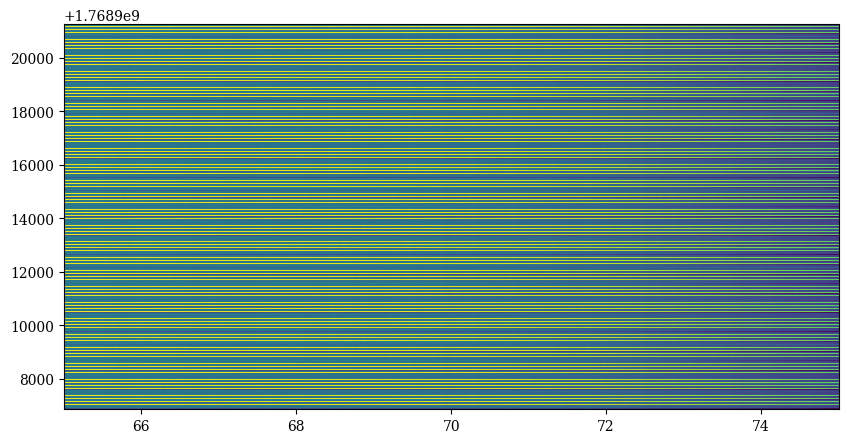

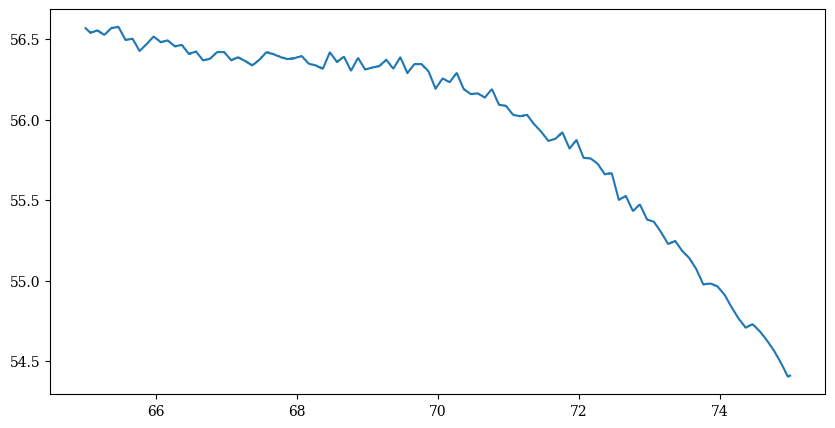

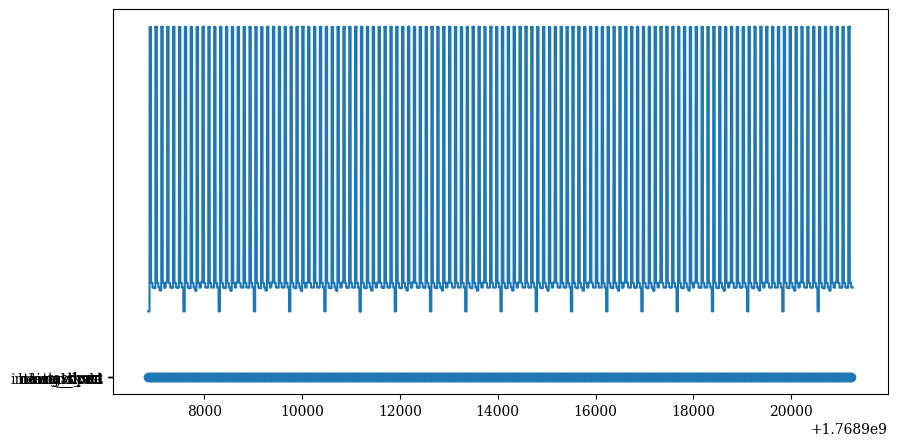

<class 'str'>
<class 'numpy.float64'>
noise_diode
[2199.89738302 2199.96365311 2199.93974335 ... 2199.95776547 2200.34372162
 2200.04202689]
----
heated_load
[328.06357569 327.96028335 327.98655393 ... 328.02590373 327.93674042
 328.00299476]
----
internal_load
[295.02328606 294.96982054 295.09376708 ... 295.01469407 294.96615511
 294.9701869 ]
----
open
[295.11481905 295.0034242  295.02339359 ... 294.95432518 295.1898035
 294.84850365]
----
short
[295.13945863 294.97507771 295.00071429 ... 295.17875715 295.22675646
 294.97908459]
----
long_open
[294.98889195 295.03828052 294.85842334 ... 294.90027197 295.21302648
 295.11838202]
----
long_short
[294.71257749 295.04074876 295.02364528 ... 295.02649585 294.85685517
 295.01391478]
----
test_src
[294.91262284 294.99786303 295.08889586 ... 295.03575288 295.16613282
 294.81048191]
----


In [10]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


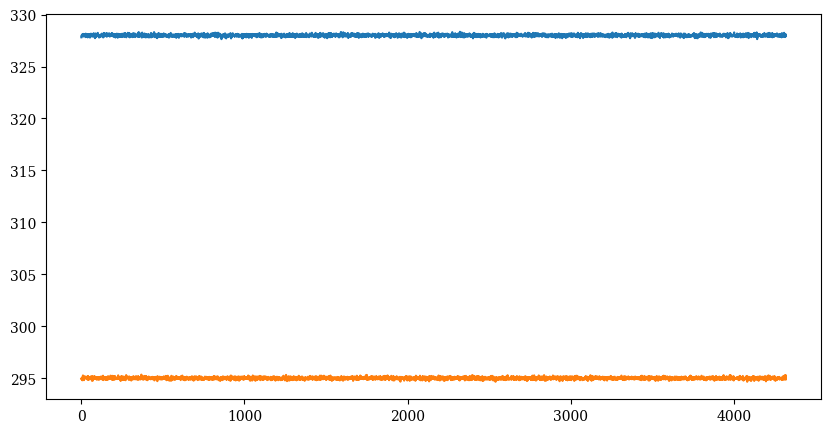

In [7]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [213]:
print(observation_handler_obj.data.shape)
print(observation_handler_obj.data)

(8640, 1024)
[[287135.11280594 291361.81300183 292372.47922927 ...  60217.62863102
   60015.11892863  59633.66848658]
 [289737.00245071 291014.35310139 292598.15309642 ...  60351.72454574
   59938.32866847  59694.78335806]
 [287122.36876488 291240.4334797  292574.33126025 ...  60353.98159724
   60365.04223851  59755.10961531]
 ...
 [266040.02220889 266642.7897186  269090.43173619 ...  51361.26500106
   50600.65590868  50424.22913121]
 [265840.39111655 267692.39565047 268086.50884199 ...  51614.82041453
   50671.32051185  50130.4498148 ]
 [266045.86488912 267073.12206983 271152.36131789 ...  51532.00224692
   50652.320987    50388.37947243]]


In [214]:
print(observation_handler_obj.temperature_dict)

{'internal_load': array([292.81496781, 293.01303276, 293.06428097, ..., 293.07576724,
       292.95604935, 293.05189933], shape=(8640,)), 'heated_load': array([333.10698535, 333.05002676, 333.00848992, ..., 332.93713033,
       332.98093049, 332.88122997], shape=(8640,)), 'long_open': array([292.98595405, 293.05042472, 293.03337481, ..., 292.98896735,
       292.98179851, 292.97077167], shape=(8640,)), 'long_short': array([292.90717372, 292.99400494, 293.07206484, ..., 292.92241352,
       292.84911875, 292.88852222], shape=(8640,)), 'open': array([292.82738047, 292.99913916, 292.98206317, ..., 293.0037069 ,
       293.04013091, 292.89735016], shape=(8640,)), 'short': array([293.11624081, 293.00861642, 293.1201259 , ..., 293.10390479,
       292.98948266, 293.05631314], shape=(8640,)), 'Test_src': array([300.06849287, 300.23662936, 299.79955941, ..., 300.17887763,
       299.86335184, 299.96781509], shape=(8640,))}


In [215]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [216]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


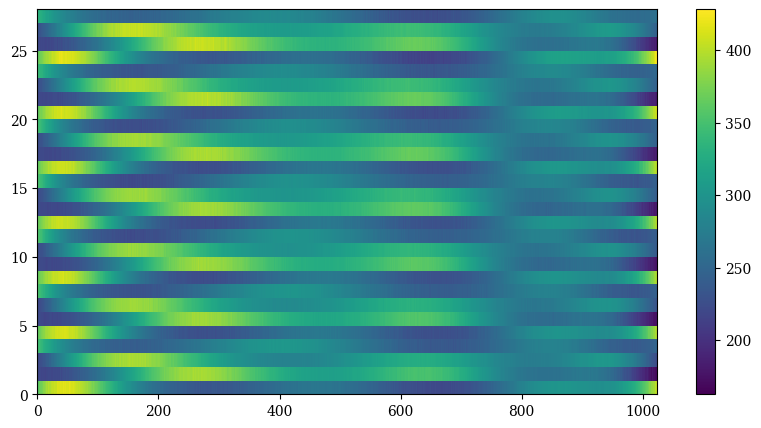

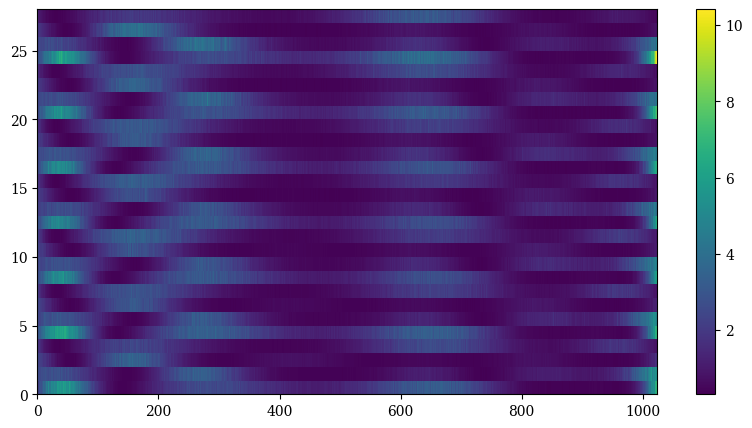

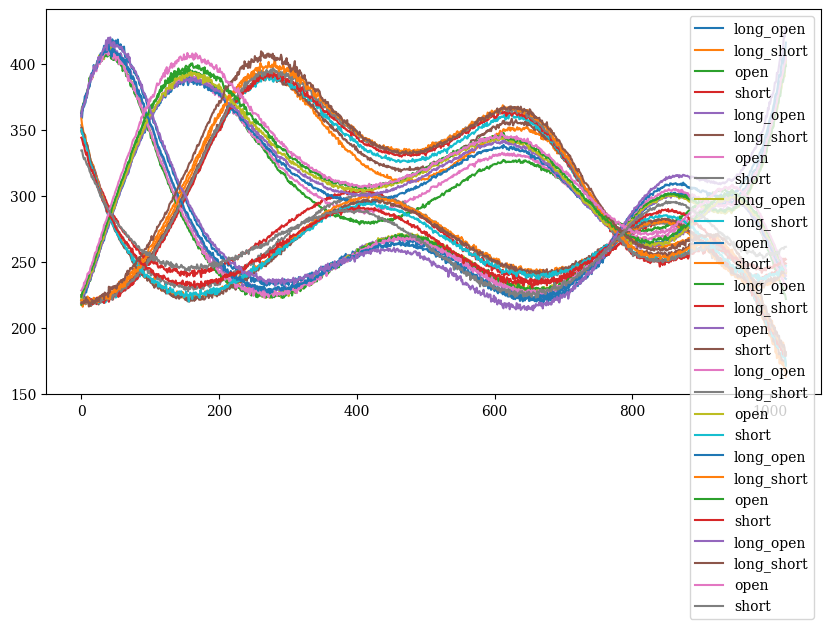

In [217]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [218]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [219]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

print(np.array(observation_handler_obj.freqs[0]))
print(type(np.array(observation_handler_obj.freqs[0])))

print(final_times[0])
print(type(np.array(final_times[0])))

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


60.0
<class 'numpy.ndarray'>
1768907003.5912335
<class 'numpy.ndarray'>
<function array_normalisation.<locals>.array_norm_func at 0x10f3d2660>


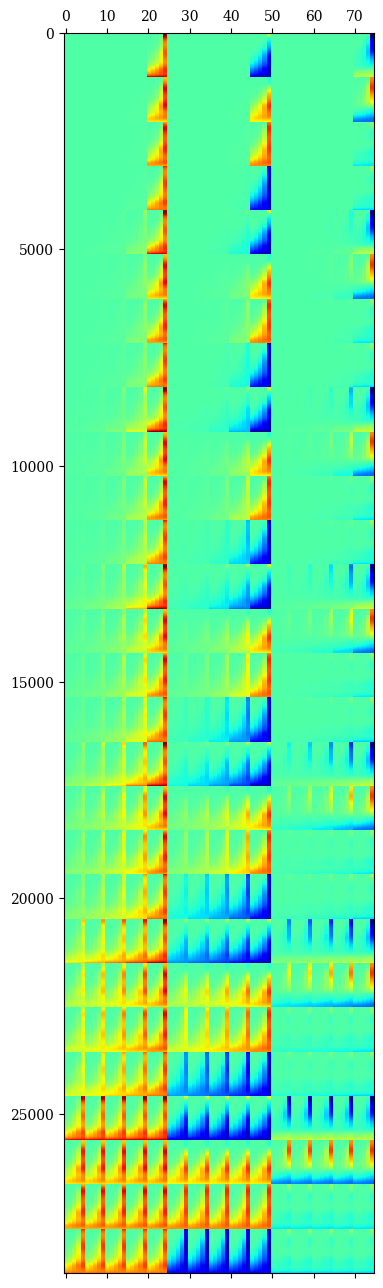

In [220]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(28672,)
(28672, 75)
[-4.21253769e+02  9.47333128e+02 -7.37830790e+02  2.24962196e+02
 -1.68353122e+01  8.57774067e+02 -1.95535842e+03  1.54751788e+03
 -4.78554996e+02  3.63641744e+01 -5.62548780e+03  1.20233254e+04
 -8.13124489e+03  1.78704818e+03 -4.79196915e+01  5.25263613e+03
 -1.09594786e+04  7.14628391e+03 -1.45604485e+03  2.68341697e+01
 -6.73995608e+02  1.53476471e+03 -1.08732337e+03  2.22865573e+02
  2.97582750e+02 -1.15860627e+02  2.40885967e+02 -1.68762105e+02
  4.54233788e+01 -4.21031513e+00  3.48691218e+02 -7.31914771e+02
  5.09755722e+02 -1.29620877e+02  9.38455525e+00  2.99358570e+02
 -1.58641027e+03  1.78210913e+03 -5.60864787e+02  1.77883162e+01
  7.36703557e+02 -3.50442606e+02 -7.55150396e+02  4.31241357e+02
 -1.08473848e+01 -5.97664027e+02  1.20589207e+03 -7.25244823e+02
  1.25235529e+02  8.32855068e+00 -4.55488236e+02  6.57503001e+02
 -1.75986530e+02 -6.08787325e+01  1.47593245e+01  8.22243419e+02
 -1.17652171e+03  2.82431146e+02  1.40226425e+02 -3.16227293e+01
 -3.

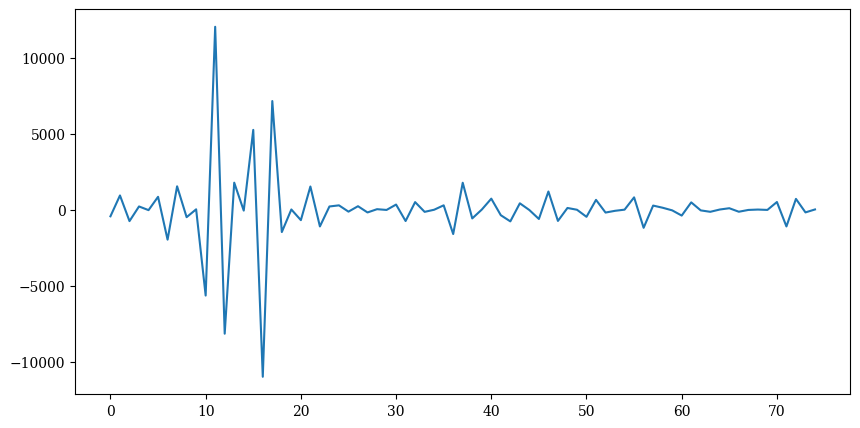

In [221]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [222]:
from gcr.basis_construction import reconstruct_surface

In [223]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[  -421.25376853    947.3331275    -737.83078988    224.9621956
    -16.83531218    857.77406747  -1955.35841912   1547.51788082
   -478.55499554     36.36417442  -5625.48779503  12023.32540396
  -8131.2448884    1787.0481836     -47.91969155   5252.63612894
 -10959.47862528   7146.2839122   -1456.04485235     26.8341697
   -673.99560843   1534.7647107   -1087.32336652    222.86557296
    297.58275041]
[ -115.86062701   240.88596672  -168.76210497    45.4233788
    -4.21031513   348.69121828  -731.914771     509.75572249
  -129.6208769      9.38455525   299.35857019 -1586.41027065
  1782.10912529  -560.86478748    17.78831618   736.70355738
  -350.44260558  -755.15039601   431.24135655   -10.84738479
  -597.66402684  1205.89206853  -725.2448231    125.23552906
     8.32855068]
[ -455.48823587   657.50300116  -175.98652965   -60.87873248
    14.75932452   822.24341858 -1176.52171498   282.43114572
   140.22642497   -31.62272929  -373.99605651   492.3890415
   -33.44768473  -126.79255462

In [224]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


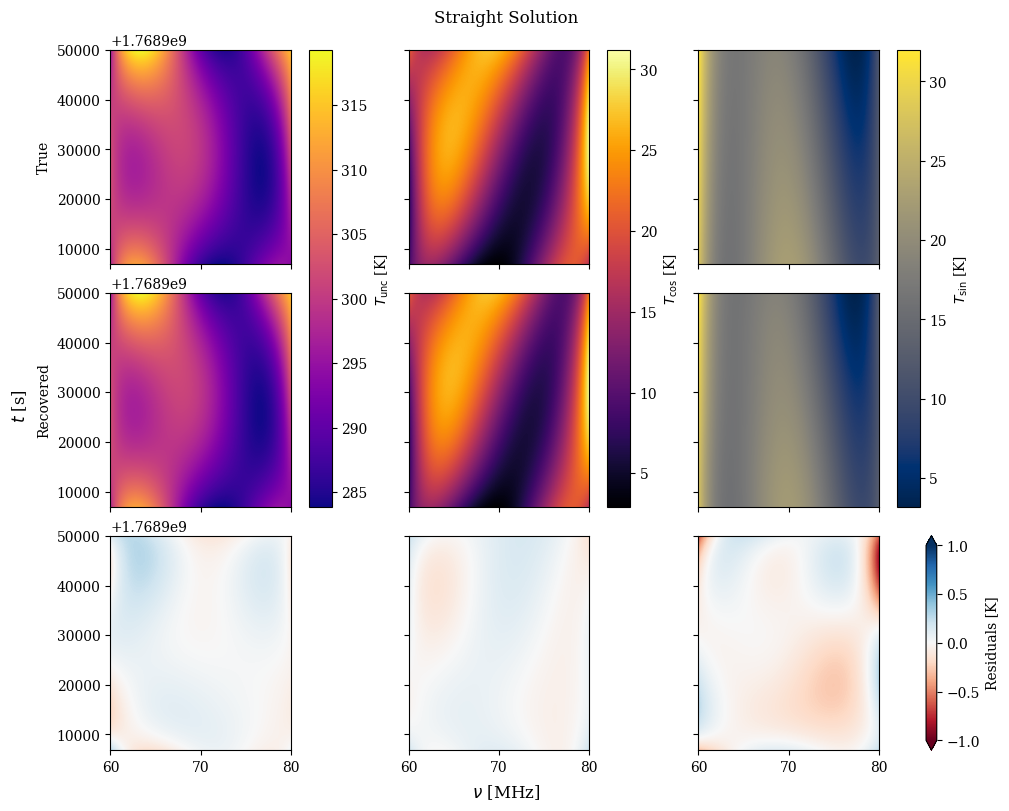

In [225]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [226]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [227]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[  -421.25357214    947.3333996    -737.83166946    224.96029751
    -16.83748309    857.77515919  -1955.35806827   1547.51785323
   -478.55711651     36.36190763  -5625.48608777  12023.32725546
  -8131.24428146   1787.04730869    -47.92232338   5252.64030585
 -10959.47499191   7146.28724219  -1456.04384292     26.83415612
   -673.98899831   1534.77185899  -1087.31692775    222.87169903
    297.58899449]
[ -115.85738806   240.88969918  -168.75884439    45.42674829
    -4.2077238    348.69548218  -731.91090919   509.75980746
  -129.61783955     9.38649287   299.36369704 -1586.4056507
  1782.11372744  -560.86182147    17.78863769   736.70964223
  -350.43736908  -755.14625975   431.24348815   -10.85130336
  -597.66079056  1205.89318132  -725.24857048   125.22449051
     8.30356993]
[ -455.490202     657.50134246  -175.98877227   -60.88132638
    14.75761903   822.24166554 -1176.52403626   282.42902249
   140.22377657   -31.62575686  -373.99856818   492.38673847
   -33.4507476   -126.79645

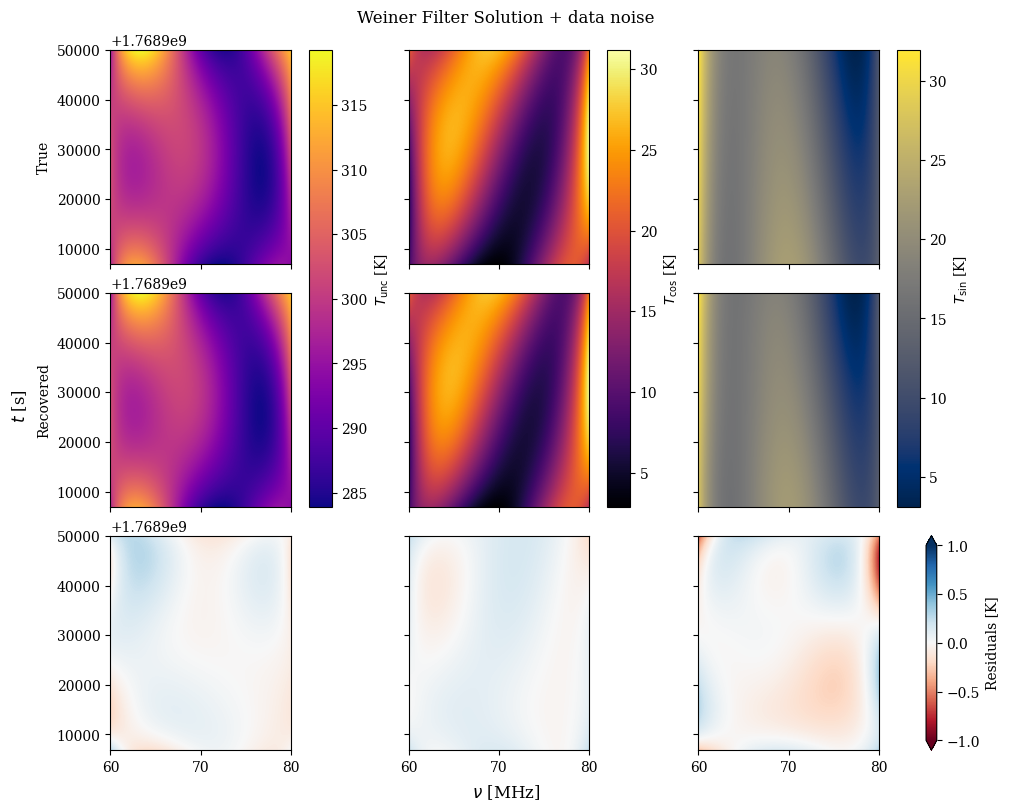

In [228]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [229]:
t_vec - gcr_wsol

array([-1.96396097e-04, -2.72101965e-04,  8.79584505e-04,  1.89809208e-03,
        2.17090935e-03, -1.09172846e-03, -3.50847198e-04,  2.75884786e-05,
        2.12096769e-03,  2.26678491e-03, -1.70725947e-03, -1.85150618e-03,
       -6.06932012e-04,  8.74916855e-04,  2.63183538e-03, -4.17691105e-03,
       -3.63337153e-03, -3.32998985e-03, -1.00942815e-03,  1.35820245e-05,
       -6.61011350e-03, -7.14829104e-03, -6.43877468e-03, -6.12606888e-03,
       -6.24407829e-03, -3.23894478e-03, -3.73246194e-03, -3.26058390e-03,
       -3.36949315e-03, -2.59133044e-03, -4.26389921e-03, -3.86181074e-03,
       -4.08496498e-03, -3.03735045e-03, -1.93761805e-03, -5.12685673e-03,
       -4.61994614e-03, -4.60214792e-03, -2.96601775e-03, -3.21514140e-04,
       -6.08485226e-03, -5.23649619e-03, -4.13626865e-03, -2.13160457e-03,
        3.91857206e-03, -3.23628195e-03, -1.11278816e-03,  3.74738222e-03,
        1.10385533e-02,  2.49807494e-02,  1.96613078e-03,  1.65870737e-03,
        2.24262566e-03,  